# GBDTE — All Dataset Experiments

A single, self-contained tour of every dataset behind the paper and every claim, with the
data properties, columns, record counts, per-column statistics, the experiments, and the
figures that illustrate the claims.

**How to read this.** Each dataset is *profiled* the same way (description → shape →
columns → `describe()` of every column → a structure plot). Then the **diagnostic** (a
data-computable pre-training screen) is computed for all of them, and finally the
**results** show where — and why — role-separated linear leaves (GBDTE) beat conventional
constant-leaf boosters.

Rigorous multi-seed numbers are loaded from the committed report
`reports/article_experiments/hunt/family_bootstrap.csv`; everything else is computed live.
Claim labels (C1…C9) match `gbdte_article_2026/results_claims.md`.

In [1]:
import sys, os
_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))  # notebooks/experiments -> repo root
sys.path.insert(0, os.path.join(_root, "python"))
os.chdir(_root)                        # so report paths resolve
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 120); pd.set_option("display.max_columns", 40)

from extra_boost_py.experiments.realdata import load_real, REAL_DATASETS
from extra_boost_py.experiments.rolestat import separability_index, extrapolation_gain
plt.rcParams["figure.dpi"] = 110

In [2]:
def profile(bench, title, description):
    """Print the standard profile of a modelling frame and plot its target over time."""
    df = bench.df
    print(f"### {title}")
    print(description.strip())
    print(f"\nrecords: {len(df):,}   features: {len(bench.partition_cols)}   "
          f"task: {bench.task}   temporal split cut(t)={bench.cut:.3f}   "
          f"train={len(bench.train):,} test={len(bench.test):,}")
    print(f"partition (interpolation) columns: {bench.partition_cols}")
    print(f"extrapolation columns: {bench.extra_cols}")
    print("\nper-column statistics (modelling frame):")
    display(df.describe().T[["count","mean","std","min","50%","max"]])
    # structure plot: target vs time
    fig, ax = plt.subplots(figsize=(6,3))
    s = df.sample(min(4000, len(df)), random_state=0)
    ax.scatter(s["t"], s["y"], s=4, alpha=0.3)
    ax.axvline(bench.cut, color="C3", ls="--", lw=1, label="train/test split")
    ax.set_xlabel("t (normalised time)"); ax.set_ylabel("y (target)")
    ax.set_title(f"{title}: target over time"); ax.legend()
    plt.tight_layout(); plt.show()
try:
    display
except NameError:
    from IPython.display import display

## Part A — Synthetic benchmarks

These encode the mechanism in controllable form: latent groups (from partition features)
whose target follows a per-group function of time, evaluated by a *forward* temporal
split. They provide the statistical backbone (Claims **C1–C4**).

### A1. MSE family (grouped drifting trend)

`y = φ(t)ᵀβ_g(Xₚ) + ε` — each latent group `g` has its own coefficients over a basis
`φ(t) = (1, t, sin ωt, cos ωt)`. Knobs: number of groups `k`, **role purity ρ** (1 = clean
role separation, 0 = none), **drift** strength. Train on `t<0.5`, predict `t≥0.5`.

### MSE family (k=8, ρ=1)
Synthetic. Groups from binary partition features f_*; leaf basis (1,t,sin,cos). Claim C1: with correct roles GBDTE nears the per-group-linear upper bound while constant-leaf boosters are ~40-100x worse (see reports/article_experiments/baselines_mse).

records: 4,000   features: 4   task: mse   temporal split cut(t)=0.500   train=2,031 test=1,969
partition (interpolation) columns: ['f_0', 'f_1', 'f_2', 'f_m']
extrapolation columns: ['e_0', 'e_1', 'e_2', 'e_3']

per-column statistics (modelling frame):


,count,mean,std,min,50%,max
f_0,4000.0,0.490750,0.499977,0.000000,0.000000,1.000000
f_1,4000.0,0.490500,0.499972,0.000000,0.000000,1.000000
f_2,4000.0,0.513000,0.499893,0.000000,1.000000,1.000000
f_m,4000.0,0.500494,0.289325,0.000108,0.505353,0.999997
t,4000.0,0.496618,0.288265,0.000190,0.491933,0.999566
e_0,4000.0,1.000000,0.000000,1.000000,1.000000,1.000000
e_1,4000.0,0.496618,0.288265,0.000190,0.491933,0.999566
e_2,4000.0,0.141501,0.691086,-0.999999,0.272376,1.000000
e_3,4000.0,0.119861,0.698750,-0.999999,0.226048,0.999999
y,4000.0,-0.138874,1.651625,-4.466456,-0.026143,2.821280


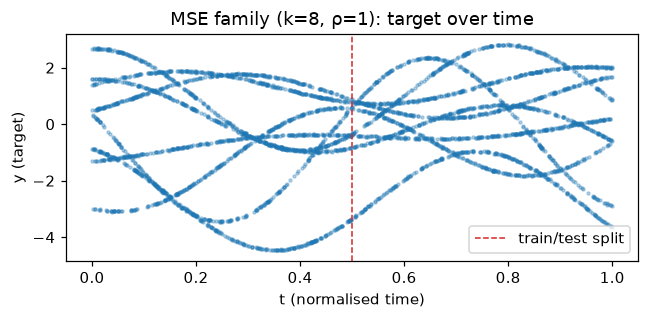

In [3]:
from extra_boost_py.experiments.benchgen import BenchConfig, generate
mse = generate(BenchConfig(task="mse", k_groups=8, omega=8.0, rho=1.0, drift=1.0, n_rows=4000, seed=0))
profile(mse, "MSE family (k=8, ρ=1)",
        "Synthetic. Groups from binary partition features f_*; leaf basis (1,t,sin,cos). "
        "Claim C1: with correct roles GBDTE nears the per-group-linear upper bound while "
        "constant-leaf boosters are ~40-100x worse (see reports/article_experiments/baselines_mse).")

### A2. LogLoss benchmark (time-dependent uplift, with a Bayes oracle)

Binary target whose class-conditional feature informativeness **reverses over time**; the
Bayes-optimal score is known in closed form. Claim **C2**.

### LogLoss benchmark
Synthetic binary. 17 partition features + (1,t) leaf basis; oracle column stored. Claim C2: GBDTE is the only practical model above chance in the future window (reports/article_experiments/baselines_logloss).

records: 8,000   features: 17   task: logloss   temporal split cut(t)=0.400   train=3,221 test=4,779
partition (interpolation) columns: ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16']
extrapolation columns: ['e_0', 'e_1']

per-column statistics (modelling frame):


,count,mean,std,min,50%,max
f_0,8000.0,0.241250,0.427868,0.000000,0.000000,1.000000
f_1,8000.0,0.124625,0.330314,0.000000,0.000000,1.000000
f_2,8000.0,0.123625,0.329174,0.000000,0.000000,1.000000
f_3,8000.0,0.124875,0.330598,0.000000,0.000000,1.000000
f_4,8000.0,0.119250,0.324103,0.000000,0.000000,1.000000
f_5,8000.0,0.124625,0.330314,0.000000,0.000000,1.000000
f_6,8000.0,0.118125,0.322776,0.000000,0.000000,1.000000
f_7,8000.0,0.126000,0.331870,0.000000,0.000000,1.000000
f_8,8000.0,0.126625,0.332573,0.000000,0.000000,1.000000
f_9,8000.0,0.246250,0.430853,0.000000,0.000000,1.000000


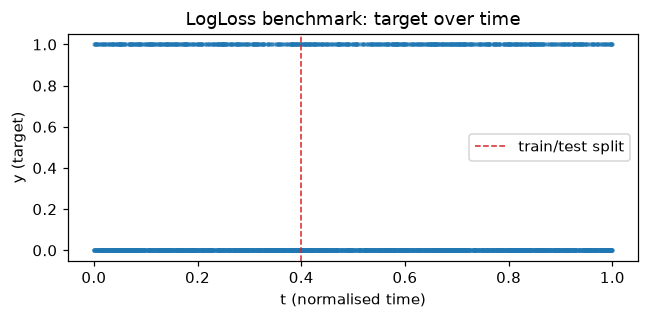

In [4]:
from extra_boost_py.experiments.classical_bench import classical_bench
ll = classical_bench(n_rows=8000, seed=0)
profile(ll, "LogLoss benchmark",
        "Synthetic binary. 17 partition features + (1,t) leaf basis; oracle column stored. "
        "Claim C2: GBDTE is the only practical model above chance in the future window "
        "(reports/article_experiments/baselines_logloss).")

### A3. Poisson benchmark (grouped drifting event intensity)

Counts with a per-group linear-in-time intensity `λ_g(t)`. *Scope note (L4):* the engine's
multi-stage bug is fixed and the leaf model is validated, but a tree-split-criterion
instability keeps Poisson out of the paper's claims for now
(`docs/poisson_mode/README.md`).

In [5]:
from extra_boost_py.experiments.poisson_bench import PoissonBenchConfig, generate_poisson
pois = generate_poisson(PoissonBenchConfig(k_groups=8, n_objects=500, seed=0))
print("Poisson bench:", len(pois.df), "object-bin rows,", len(pois.partition_cols), "features, task", pois.task)
display(pois.df[["t","y","lam_true","group"]].describe().T[["mean","std","min","50%","max"]])

Poisson bench: 10000 object-bin rows, 4 features, task poisson


,mean,std,min,50%,max
t,0.500000,0.288328,0.025000,0.500000,0.975000
y,3.372800,2.138242,1.000000,3.000000,17.000000
lam_true,65.827015,25.037641,31.540515,56.133647,131.995526
group,3.700000,2.339775,0.000000,4.000000,7.000000


### A4. The regime map (C3) and the diagnostic-vs-ρ validation (C4)

The central synthetic figure: GBDTE's advantage as a function of role purity ρ and drift.
Linear leaves help only in the high-ρ / drift region. Rendered report:
`reports/article_experiments/regime_map/regime_map.pdf`; the separability index is monotone
in ρ (`rolestat_validation/separability_vs_rho.pdf`).

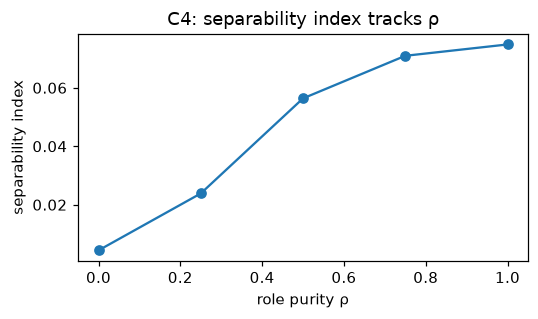

In [6]:
from dataclasses import replace
base = BenchConfig(task="mse", k_groups=32, basis="fourier", omega=8.0, noise=0.05, n_rows=3000)
rhos = [0.0,0.25,0.5,0.75,1.0]
seps = [np.mean([separability_index(generate(replace(base, rho=r, seed=s))) for s in range(3)]) for r in rhos]
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(rhos, seps, "o-"); ax.set_xlabel("role purity ρ"); ax.set_ylabel("separability index")
ax.set_title("C4: separability index tracks ρ"); plt.tight_layout(); plt.show()

## Part B — Real datasets (properties, columns, records, statistics)

Nine public datasets with genuine temporal (train-past / predict-future) splits. Five lack
the structure GBDTE exploits (the honest negatives, **C6**); four are the OWID country-panel
family where GBDTE wins (**C7**). Each is profiled identically below.

In [7]:
REAL = [
 ("weather", "TabReD Weather — hourly meteorological readings; regression on temperature. "
             "Periodic (diurnal/seasonal) structure — a negative for GBDTE (C6, C9)."),
 ("sberbank", "Sberbank Russian housing — property sale prices over 2011-2015; regression. "
              "Some trend but weak group structure (C6)."),
 ("homecredit", "Home Credit default risk — loan applications with date_decision; "
                "classification. The credit-scoring domain the abstract names (C6)."),
 ("latam", "LatAm fintech — monthly transaction-activity forecasting from a 48k-client "
           "panel with a leakage-safe static client card; regression (C6)."),
 ("gassensor", "UCI Gas Sensor Array Drift — 128 sensor features, 10 time-ordered batches; "
               "one-vs-rest classification. Sensor drift, but no per-class forward trend (C6)."),
 ("owid_childmort", "OWID child mortality — country x year, country withheld (continent + "
                    "initial level as features), log target; regression. FAMILY (C7)."),
 ("owid_maternalmort", "OWID maternal mortality ratio — same recipe, log target. FAMILY (C7)."),
 ("owid_lifeexp", "OWID life expectancy — same recipe, no log (bounded, ~linear). FAMILY (C7)."),
 ("owid_gdppcap", "OWID GDP per capita — same recipe, log target. FAMILY (C7, tie)."),
]

### weather

### weather
TabReD Weather — hourly meteorological readings; regression on temperature. Periodic (diurnal/seasonal) structure — a negative for GBDTE (C6, C9).

records: 20,000   features: 102   task: mse   temporal split cut(t)=0.810   train=14,999 test=5,001
partition (interpolation) columns: ['apply_time_rl', 'climate_pressure', 'climate_temperature', 'cmc_0_0_0_1000', 'cmc_0_0_0_2', 'cmc_0_0_0_2_grad', 'cmc_0_0_0_2_interpolated', 'cmc_0_0_0_2_next', 'cmc_0_0_0_500', 'cmc_0_0_0_700', 'cmc_0_0_0_850', 'cmc_0_0_0_925', 'cmc_0_0_6_2', 'cmc_0_0_7_1000', 'cmc_0_0_7_2', 'cmc_0_0_7_500', 'cmc_0_0_7_700', 'cmc_0_0_7_850', 'cmc_0_0_7_925', 'cmc_0_1_0_0', 'cmc_0_1_11_0', 'cmc_0_1_65_0', 'cmc_0_1_66_0', 'cmc_0_1_67_0', 'cmc_0_1_68_0', 'cmc_0_1_7_0', 'cmc_0_2_2_10', 'cmc_0_2_2_1000', 'cmc_0_2_2_500', 'cmc_0_2_2_700', 'cmc_0_2_2_850', 'cmc_0_2_2_925', 'cmc_0_2_3_10', 'cmc_0_2_3_1000', 'cmc_0_2_3_500', 'cmc_0_2_3_700', 'cmc_0_2_3_850', 'cmc_0_2_3_925', 'cmc_0_3_0_0', 'cmc_0_3_0_0_next', 'cmc_0_3_1

,count,mean,std,min,50%,max
t,20000.0,5.401272e-01,2.939222e-01,0.000000e+00,5.438969e-01,1.000000e+00
e_0,20000.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
e_1,20000.0,5.401272e-01,2.939222e-01,0.000000e+00,5.438969e-01,1.000000e+00
y,20000.0,2.689709e+01,3.912684e+00,5.000000e+00,2.700000e+01,5.800000e+01
apply_time_rl,20000.0,1.674938e+09,1.002012e+07,1.656442e+09,1.675042e+09,1.690720e+09
...,...,...,...,...,...,...
gfs_u_wind,20000.0,-8.269427e-01,3.195957e+00,-1.372901e+01,-5.307581e-01,2.469365e+01
gfs_v_wind,20000.0,2.509709e-01,2.547273e+00,-1.676964e+01,1.805737e-01,1.428256e+01
gfs_wind_speed,20000.0,3.424148e+00,2.396981e+00,2.376131e-02,2.814112e+00,2.474246e+01
sun_elevation,20000.0,9.336489e+00,4.464534e+01,-8.924448e+01,1.458506e+01,8.975252e+01


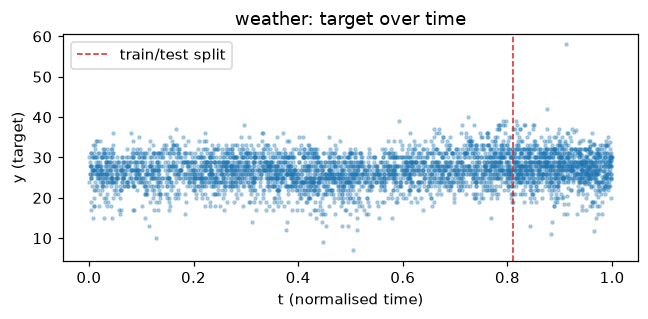

In [8]:
b = load_real("weather", seed=0, n_max=20000)
profile(b, "weather", 'TabReD Weather — hourly meteorological readings; regression on temperature. Periodic (diurnal/seasonal) structure — a negative for GBDTE (C6, C9).')

### sberbank

### sberbank
Sberbank Russian housing — property sale prices over 2011-2015; regression. Some trend but weak group structure (C6).

records: 20,000   features: 289   task: mse   temporal split cut(t)=0.804   train=14,999 test=5,001
partition (interpolation) columns: ['full_sq', 'life_sq', 'floor', 'max_floor', 'material', 'build_year', 'num_room', 'kitch_sq', 'state', 'product_type', 'sub_area', 'area_m', 'raion_popul', 'green_zone_part', 'indust_part', 'children_preschool', 'preschool_quota', 'preschool_education_centers_raion', 'children_school', 'school_quota', 'school_education_centers_raion', 'school_education_centers_top_20_raion', 'hospital_beds_raion', 'healthcare_centers_raion', 'university_top_20_raion', 'sport_objects_raion', 'additional_education_raion', 'culture_objects_top_25', 'culture_objects_top_25_raion', 'shopping_centers_raion', 'office_raion', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'bi

,count,mean,std,min,50%,max
t,20000.0,6.069605e-01,2.403700e-01,0.0,6.496454e-01,1.0
e_0,20000.0,1.000000e+00,0.000000e+00,1.0,1.000000e+00,1.0
e_1,20000.0,6.069605e-01,2.403700e-01,0.0,6.496454e-01,1.0
y,20000.0,7.139045e+06,4.760011e+06,100000.0,6.300000e+06,95122496.0
full_sq,20000.0,5.443400e+01,4.407471e+01,0.0,5.000000e+01,5326.0
...,...,...,...,...,...,...
church_count_5000,20000.0,3.040485e+01,4.768337e+01,0.0,1.600000e+01,250.0
mosque_count_5000,20000.0,4.416000e-01,6.090222e-01,0.0,0.000000e+00,2.0
leisure_count_5000,20000.0,8.711700e+00,2.068606e+01,0.0,2.000000e+00,105.0
sport_count_5000,20000.0,5.290100e+01,4.639521e+01,0.0,4.800000e+01,218.0


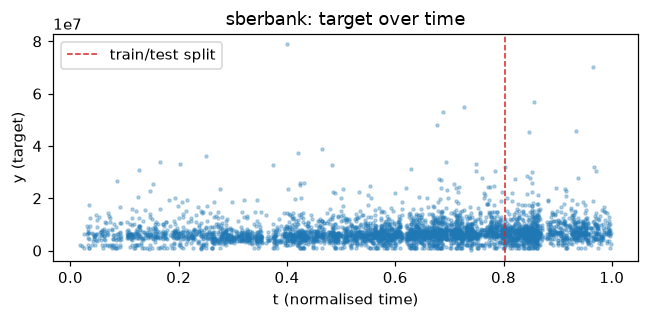

In [9]:
b = load_real("sberbank", seed=0, n_max=20000)
profile(b, "sberbank", 'Sberbank Russian housing — property sale prices over 2011-2015; regression. Some trend but weak group structure (C6).')

### homecredit

/home/tarstars/prj/extra_bridged_boosting/python/extra_boost_py/experiments/realdata.py:138: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(v)


### homecredit
Home Credit default risk — loan applications with date_decision; classification. The credit-scoring domain the abstract names (C6).

records: 20,000   features: 386   task: logloss   temporal split cut(t)=0.605   train=14,972 test=5,028
partition (interpolation) columns: ['actualdpdtolerance_344P', 'amtinstpaidbefduel24m_4187115A', 'annuity_780A', 'annuitynextmonth_57A', 'applicationcnt_361L', 'applications30d_658L', 'applicationscnt_1086L', 'applicationscnt_464L', 'applicationscnt_629L', 'applicationscnt_867L', 'avgdbddpdlast24m_3658932P', 'avgdbddpdlast3m_4187120P', 'avgdbdtollast24m_4525197P', 'avgdpdtolclosure24_3658938P', 'avginstallast24m_3658937A', 'avglnamtstart24m_4525187A', 'avgmaxdpdlast9m_3716943P', 'avgoutstandbalancel6m_4187114A', 'avgpmtlast12m_4525200A', 'bankacctype_710L', 'cardtype_51L', 'clientscnt12m_3712952L', 'clientscnt3m_3712950L', 'clientscnt6m_3712949L', 'clientscnt_100L', 'clientscnt_1022L', 'clientscnt_1071L', 'clientscnt_1130L', 'clientscnt_1

,count,mean,std,min,50%,max
t,20000.0,0.448371,0.258896,0.000000,0.438569,1.000000
e_0,20000.0,1.000000,0.000000,1.000000,1.000000,1.000000
e_1,20000.0,0.448371,0.258896,0.000000,0.438569,1.000000
y,20000.0,0.032600,0.177592,0.000000,0.000000,1.000000
actualdpdtolerance_344P,20000.0,0.008550,0.314932,0.000000,0.000000,24.000000
...,...,...,...,...,...,...
responsedate_4917613D,20000.0,16.756200,46.477111,-1.000000,-1.000000,190.000000
riskassesment_302T,20000.0,-0.710700,1.741252,-1.000000,-1.000000,15.000000
riskassesment_940T,20000.0,0.365595,0.186376,-2.835892,0.371834,1.962657
secondquarter_766L,20000.0,2.630700,3.177770,0.000000,2.000000,39.000000


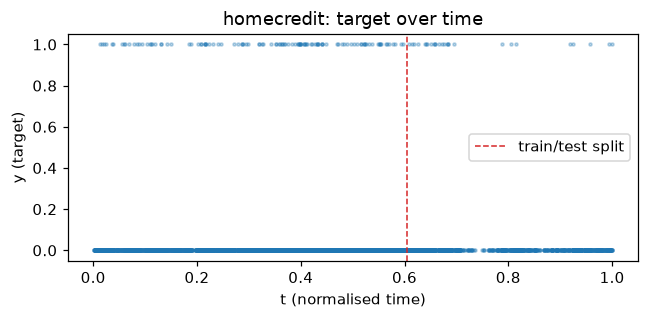

In [10]:
b = load_real("homecredit", seed=0, n_max=20000)
profile(b, "homecredit", 'Home Credit default risk — loan applications with date_decision; classification. The credit-scoring domain the abstract names (C6).')

### latam

### latam
LatAm fintech — monthly transaction-activity forecasting from a 48k-client panel with a leakage-safe static client card; regression (C6).

records: 20,000   features: 16   task: mse   temporal split cut(t)=0.817   train=14,855 test=5,145
partition (interpolation) columns: ['age', 'gender', 'location', 'income_bracket', 'occupation', 'education_level', 'marital_status', 'household_size', 'acquisition_channel', 'customer_segment', 'savings_account', 'credit_card', 'personal_loan', 'investment_account', 'insurance_product', 'active_products']
extrapolation columns: ['e_0', 'e_1']

per-column statistics (modelling frame):


,count,mean,std,min,50%,max
t,20000.0,0.501189,0.315557,0.0,0.541916,1.000000
e_0,20000.0,1.000000,0.000000,1.0,1.000000,1.000000
e_1,20000.0,0.501189,0.315557,0.0,0.541916,1.000000
y,20000.0,1.081860,0.883844,0.0,1.098612,7.995644
age,20000.0,44.327950,12.328990,29.0,44.000000,60.000000
gender,20000.0,0.525100,0.534588,0.0,1.000000,2.000000
location,20000.0,5.148450,4.084280,0.0,4.000000,17.000000
income_bracket,20000.0,1.251600,0.887714,0.0,1.000000,3.000000
occupation,20000.0,16.875750,10.167978,0.0,17.000000,34.000000
education_level,20000.0,0.853650,0.862130,0.0,1.000000,3.000000


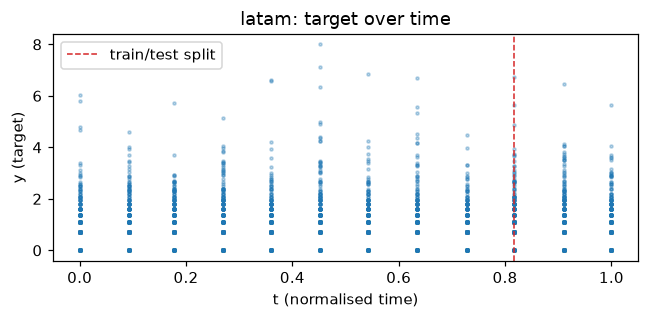

In [11]:
b = load_real("latam", seed=0, n_max=20000)
profile(b, "latam", 'LatAm fintech — monthly transaction-activity forecasting from a 48k-client panel with a leakage-safe static client card; regression (C6).')

### gassensor

### gassensor
UCI Gas Sensor Array Drift — 128 sensor features, 10 time-ordered batches; one-vs-rest classification. Sensor drift, but no per-class forward trend (C6).

records: 13,910   features: 128   task: logloss   temporal split cut(t)=1.000   train=10,310 test=3,600
partition (interpolation) columns: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27', 's28', 's29', 's30', 's31', 's32', 's33', 's34', 's35', 's36', 's37', 's38', 's39', 's40', 's41', 's42', 's43', 's44', 's45', 's46', 's47', 's48', 's49', 's50', 's51', 's52', 's53', 's54', 's55', 's56', 's57', 's58', 's59', 's60', 's61', 's62', 's63', 's64', 's65', 's66', 's67', 's68', 's69', 's70', 's71', 's72', 's73', 's74', 's75', 's76', 's77', 's78', 's79', 's80', 's81', 's82', 's83', 's84', 's85', 's86', 's87', 's88', 's89', 's90', 's91', 's92', 's93', 's94', 's95', 's96', 's97', 's98', 's99', 's100',

,count,mean,std,min,50%,max
t,13910.0,0.615728,0.310593,0.000000,0.666667,1.000000
e_0,13910.0,1.000000,0.000000,1.000000,1.000000,1.000000
e_1,13910.0,0.615728,0.310593,0.000000,0.666667,1.000000
y,13910.0,0.184400,0.387824,0.000000,0.000000,1.000000
s1,13910.0,50435.066174,69844.785952,-16757.598600,19364.439350,670687.347700
...,...,...,...,...,...,...
s124,13910.0,14.929364,12.437311,0.011488,11.325214,297.225880
s125,13910.0,19.090980,14.391810,0.118849,14.560676,195.242555
s126,13910.0,-4.901016,4.195360,-30.205911,-3.881763,-0.003817
s127,13910.0,-8.167792,7.637701,-58.844076,-6.305962,6.851792


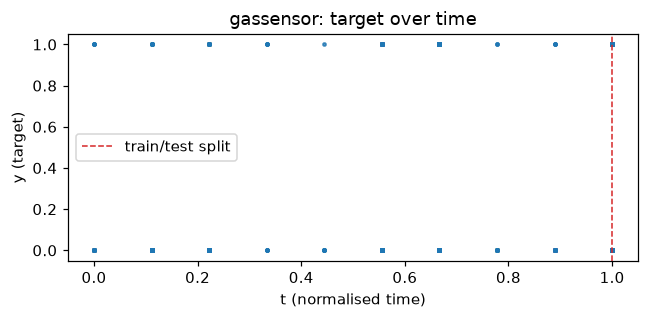

In [12]:
b = load_real("gassensor", seed=0, n_max=20000)
profile(b, "gassensor", 'UCI Gas Sensor Array Drift — 128 sensor features, 10 time-ordered batches; one-vs-rest classification. Sensor drift, but no per-class forward trend (C6).')

### owid_childmort

### owid_childmort
OWID child mortality — country x year, country withheld (continent + initial level as features), log target; regression. FAMILY (C7).

records: 16,201   features: 3   task: mse   temporal split cut(t)=0.927   train=11,994 test=4,207
partition (interpolation) columns: ['region', 'income', 'init_value']
extrapolation columns: ['e_0', 'e_1']

per-column statistics (modelling frame):


,count,mean,std,min,50%,max
t,16201.0,0.821036,0.149364,0.000000,0.853480,1.000000
e_0,16201.0,1.000000,0.000000,1.000000,1.000000,1.000000
e_1,16201.0,0.821036,0.149364,0.000000,0.853480,1.000000
y,16201.0,1.997246,0.992338,0.122218,2.009555,4.370586
region,16201.0,1.823961,1.467633,0.000000,2.000000,5.000000
income,16201.0,0.000000,0.000000,0.000000,0.000000,0.000000
init_value,16201.0,24.923144,11.867564,0.970000,25.110000,68.210000


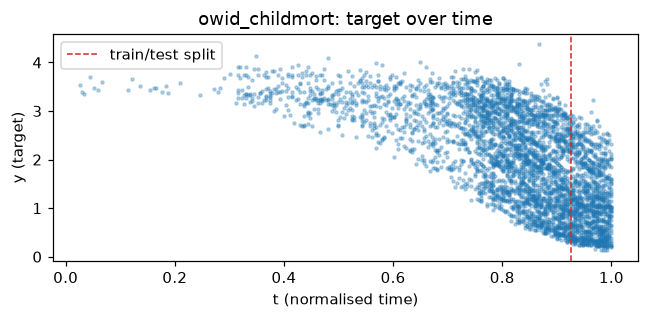

In [13]:
b = load_real("owid_childmort", seed=0, n_max=20000)
profile(b, "owid_childmort", 'OWID child mortality — country x year, country withheld (continent + initial level as features), log target; regression. FAMILY (C7).')

### owid_maternalmort

### owid_maternalmort
OWID maternal mortality ratio — same recipe, log target. FAMILY (C7).

records: 8,868   features: 3   task: mse   temporal split cut(t)=0.959   train=6,626 test=2,242
partition (interpolation) columns: ['region', 'income', 'init_value']
extrapolation columns: ['e_0', 'e_1']

per-column statistics (modelling frame):


,count,mean,std,min,50%,max
t,8868.0,0.872780,0.151213,0.000000,0.914498,1.0000
e_0,8868.0,1.000000,0.000000,1.000000,1.000000,1.0000
e_1,8868.0,0.872780,0.151213,0.000000,0.914498,1.0000
y,8868.0,4.476896,1.618093,0.715252,4.412370,8.8211
region,8868.0,1.740415,1.383433,0.000000,2.000000,5.0000
income,8868.0,0.000000,0.000000,0.000000,0.000000,0.0000
init_value,8868.0,456.882342,479.610469,9.765756,228.816760,3291.7840


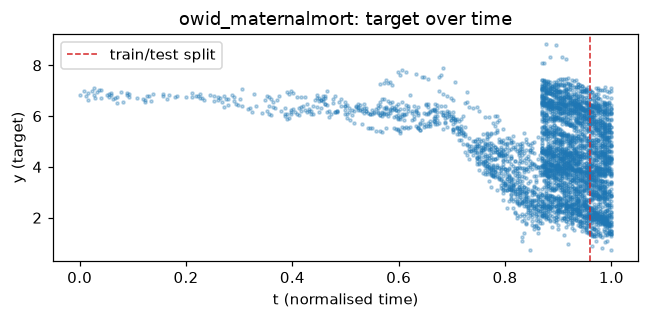

In [14]:
b = load_real("owid_maternalmort", seed=0, n_max=20000)
profile(b, "owid_maternalmort", 'OWID maternal mortality ratio — same recipe, log target. FAMILY (C7).')

### owid_lifeexp

### owid_lifeexp
OWID life expectancy — same recipe, no log (bounded, ~linear). FAMILY (C7).

records: 19,528   features: 3   task: mse   temporal split cut(t)=0.958   train=14,551 test=4,977
partition (interpolation) columns: ['region', 'income', 'init_value']
extrapolation columns: ['e_0', 'e_1']

per-column statistics (modelling frame):


,count,mean,std,min,50%,max
t,19528.0,0.904562,0.080187,0.0000,0.914583,1.0000
e_0,19528.0,1.000000,0.000000,1.0000,1.000000,1.0000
e_1,19528.0,0.904562,0.080187,0.0000,0.914583,1.0000
y,19528.0,62.103386,13.057300,10.9891,64.828850,86.3724
region,19528.0,1.877048,1.449722,0.0000,2.000000,5.0000
income,19528.0,0.000000,0.000000,0.0000,0.000000,0.0000
init_value,19528.0,42.269223,11.576791,18.9000,40.100000,71.5897


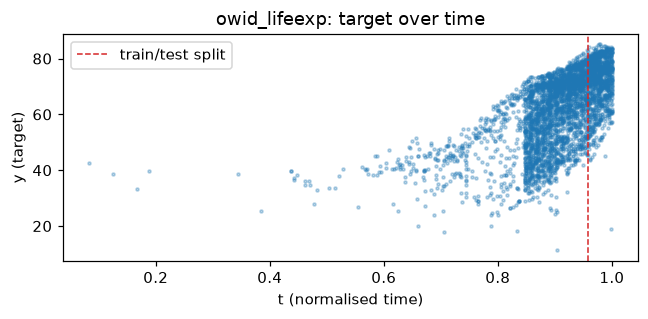

In [15]:
b = load_real("owid_lifeexp", seed=0, n_max=20000)
profile(b, "owid_lifeexp", 'OWID life expectancy — same recipe, no log (bounded, ~linear). FAMILY (C7).')

### owid_gdppcap

### owid_gdppcap
OWID GDP per capita — same recipe, log target. FAMILY (C7, tie).

records: 6,785   features: 3   task: mse   temporal split cut(t)=0.765   train=5,007 test=1,778
partition (interpolation) columns: ['region', 'income', 'init_value']
extrapolation columns: ['e_0', 'e_1']

per-column statistics (modelling frame):


,count,mean,std,min,50%,max
t,6785.0,0.506155,0.295646,0.000000,0.500000,1.000000
e_0,6785.0,1.000000,0.000000,1.000000,1.000000,1.000000
e_1,6785.0,0.506155,0.295646,0.000000,0.500000,1.000000
y,6785.0,9.371503,1.201780,6.237978,9.441319,12.070084
region,6785.0,1.693147,1.466566,0.000000,1.000000,5.000000
income,6785.0,0.000000,0.000000,0.000000,0.000000,0.000000
init_value,6785.0,17102.542289,19982.470048,547.622800,9058.666000,118163.680000


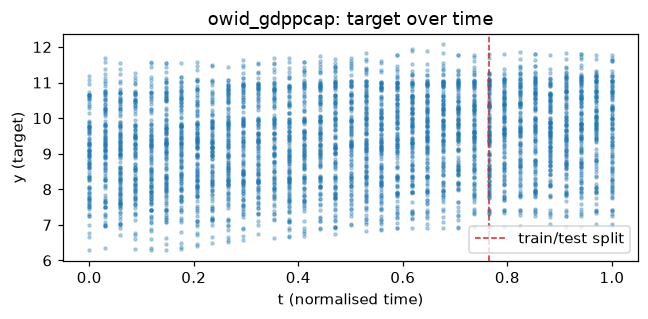

In [16]:
b = load_real("owid_gdppcap", seed=0, n_max=20000)
profile(b, "owid_gdppcap", 'OWID GDP per capita — same recipe, log target. FAMILY (C7, tie).')

## Part C — The pre-training screen (C5, the novel contribution)

Two numbers computed on the **training window only**, before any model is fit:
`separability_index` (is there stable group structure?) and `extrapolation_gain` (does a
per-group *linear-in-t* model beat a per-group *constant* on a held-out forward slice?).
The screen promotes a dataset iff `extrapolation_gain ≥ 0.05`. It was correct on all nine
datasets — and `extrapolation_gain`, not separability, is the discriminating signal.

In [17]:
rows = []
for name, _ in REAL:
    b = load_real(name, seed=0, n_max=20000)
    rows.append(dict(dataset=name, task=b.task,
                     separability=separability_index(b),
                     extrap_gain=extrapolation_gain(b)))
screen = pd.DataFrame(rows).sort_values("extrap_gain", ascending=False).reset_index(drop=True)
screen["promoted (green)"] = screen["extrap_gain"] >= 0.05
display(screen.round(3))

/home/tarstars/prj/extra_bridged_boosting/python/extra_boost_py/experiments/realdata.py:138: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(v)


,dataset,task,separability,extrap_gain,promoted (green)
0,owid_lifeexp,mse,0.386,0.694,True
1,owid_childmort,mse,0.243,0.607,True
2,owid_gdppcap,mse,0.500,0.340,True
3,owid_maternalmort,mse,0.471,0.240,True
4,sberbank,mse,0.471,0.048,False
5,gassensor,logloss,0.000,0.015,False
6,homecredit,logloss,0.118,0.001,False
7,weather,mse,0.064,0.000,False
8,latam,mse,0.200,0.000,False


**The screen figure.** `extrapolation_gain` cleanly separates the family (green) from
the negatives — and note Sberbank has the *highest* separability yet no forward headroom,
so separability alone would mislead.

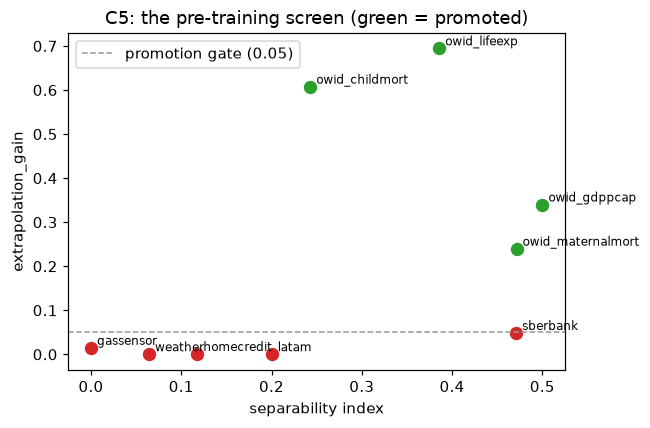

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
for _, r in screen.iterrows():
    col = "C2" if r["extrap_gain"] >= 0.05 else "C3"
    ax.scatter(r["separability"], r["extrap_gain"], c=col, s=60)
    ax.annotate(r["dataset"], (r["separability"], r["extrap_gain"]),
                fontsize=8, xytext=(4,2), textcoords="offset points")
ax.axhline(0.05, color="0.6", ls="--", lw=1, label="promotion gate (0.05)")
ax.set_xlabel("separability index"); ax.set_ylabel("extrapolation_gain")
ax.set_title("C5: the pre-training screen (green = promoted)"); ax.legend()
plt.tight_layout(); plt.show()

## Part D — Results: where and why GBDTE wins (C7, C8)

Rigorous 10-bootstrap test RMSE (resampled training set, fixed forward test window), loaded
from the committed report. GBDTE beats the standard constant-leaf boosters
(XGBoost/LightGBM/CatBoost) on 3 of the 4 family panels by 12–24% and ties on GDP; on
maternal mortality it is the single best model.

In [19]:
fam = pd.read_csv("reports/article_experiments/hunt/family_bootstrap.csv")
pivot = fam.pivot(index="dataset", columns="model", values="mean")
order = ["owid_childmort","owid_maternalmort","owid_lifeexp","owid_gdppcap"]
show = ["gbdte_auto","xgb","lgbm","catboost","detrend_lgbm","gbdte_const"]
display(fam[fam.model.isin(show)].pivot_table(index="dataset", columns="model", values="mean").loc[order].round(3))

model,catboost,detrend_lgbm,gbdte_auto,gbdte_const,lgbm,xgb
dataset,,,,,,
owid_childmort,0.504,0.320,0.323,1.151,0.430,0.422
owid_maternalmort,0.638,0.470,0.431,1.009,0.516,0.491
owid_lifeexp,6.530,4.399,4.691,14.523,5.566,5.523
owid_gdppcap,0.339,0.261,0.252,0.498,0.267,0.250


**The family figure.** GBDTE vs the best standard booster on each panel (lower is
better). GBDTE bars are shorter on 3 of 4; error bars are the bootstrap std.

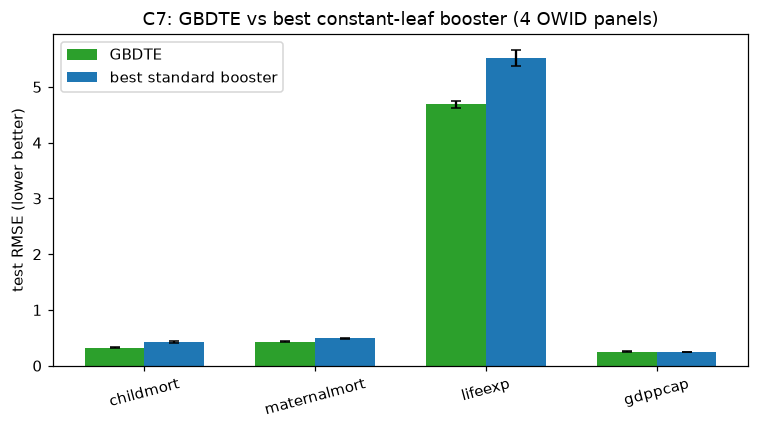

In [20]:
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(order)); w = 0.35
def series(model):
    m = fam[fam.model==model].set_index("dataset").loc[order]
    return m["mean"].to_numpy(), m["std"].to_numpy()
gm, gs = series("gbdte_auto")
# best booster per dataset among xgb/lgbm/catboost
boost = fam[fam.model.isin(["xgb","lgbm","catboost"])]
bb = boost.loc[boost.groupby("dataset")["mean"].idxmin()].set_index("dataset").loc[order]
bm, bs = bb["mean"].to_numpy(), bb["std"].to_numpy()
ax.bar(x-w/2, gm, w, yerr=gs, capsize=3, label="GBDTE", color="C2")
ax.bar(x+w/2, bm, w, yerr=bs, capsize=3, label="best standard booster", color="C0")
ax.set_xticks(x); ax.set_xticklabels([d.replace("owid_","") for d in order], rotation=15)
ax.set_ylabel("test RMSE (lower better)")
ax.set_title("C7: GBDTE vs best constant-leaf booster (4 OWID panels)"); ax.legend()
plt.tight_layout(); plt.show()

### Why GBDTE wins — the mechanism, visualised

On child mortality, the target declines steeply and the forward test window lies *below*
anything seen in training. A constant-leaf booster can only predict the last training
level (it flattens); GBDTE's linear leaf carries the per-group trend into the future. This
is the whole thesis in one picture (C8).

In [21]:
from extra_boost_py.experiments.baselines import make_real_models
from extra_boost_py.experiments.stats import evaluate
b = load_real("owid_childmort", seed=0, n_max=20000)
M = make_real_models("mse")
preds = {}
for n in ["gbdte_auto","lgbm"]:
    m = M[n]; m.fit(b); preds[n] = m.predict(b.df)
df = b.df.copy(); df["gbdte"] = preds["gbdte_auto"]; df["lgbm"] = preds["lgbm"]
agg = df.groupby(pd.cut(df["t"], 40, labels=False)).agg(
    t=("t","mean"), y=("y","mean"), gbdte=("gbdte","mean"), lgbm=("lgbm","mean")).dropna()
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(agg["t"], agg["y"], "k.", label="actual (log child mortality)")
ax.plot(agg["t"], agg["gbdte"], "C2-", label="GBDTE (linear leaf)")
ax.plot(agg["t"], agg["lgbm"], "C0-", label="LightGBM (constant leaf)")
ax.axvline(b.cut, color="C3", ls="--", lw=1, label="train/test split")
ax.set_xlabel("t (normalised year)"); ax.set_ylabel("mean log(1+rate)")
ax.set_title("C8: constant leaves flatten in the future; linear leaves extrapolate")
ax.legend(); plt.tight_layout(); plt.show()
print("test RMSE — GBDTE:", round(evaluate(M['gbdte_auto'], b)['rmse'],3),
      " LightGBM:", round(evaluate(M['lgbm'], b)['rmse'],3))

/home/tarstars/prj/extra_bridged_boosting/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/tmp/ipykernel_76644/421271845.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.legend(); plt.tight_layout(); plt.show()
/home/tarstars/prj/extra_bridged_boosting/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


test RMSE — GBDTE: 0.319  LightGBM: 0.421


### The periodicity caveat (C9)

On Weather the periodogram recovers the 1.00-day diurnal cycle *exactly*, yet giving all
models that sin/cos basis **hurts** GBDTE (2.39 vs 1.86 RMSE): a periodic basis folds the
future back into the observed range, converting extrapolation into interpolation that any
booster handles. The linear-leaf advantage is therefore specific to *aperiodic* drift.
Report: `reports/article_experiments/realdata_basis_weather/`.

## Summary — the claims and their evidence

| Claim | Statement | Evidence |
|---|---|---|
| C1 | MSE: linear leaves ≫ constant leaves | `baselines_mse` |
| C2 | LogLoss: GBDTE best non-oracle in future window | `baselines_logloss` |
| C3 | Regime map: help iff role purity + drift | `regime_map` |
| C4 | Separability tracks ρ | this notebook / `rolestat_validation` |
| **C5** | **Pre-training screen predicts where linear leaves help (9/9)** | Part C, `hunt/screen*` |
| C6 | Five honest public negatives, all predicted | Part B, `realdata` |
| **C7** | **Family of 4 OWID panels: win 3, tie 1** | Part D, `hunt/family_bootstrap.csv` |
| C8 | Advantage = regularized linear extrapolation | Part D figure |
| C9 | Periodic basis → interpolation (aperiodic-only) | `realdata_basis_weather` |

Wording/scope decisions are collected in `gbdte_article_2026/results_claims.md`.